# Get the 32 GPS satellites' positions in ECEF & HTML visualisation

This notebook visualizes:
1. An oblate Earth sphere in ECEF coordinates
2. All TART telescope positions being used during t_obs
3. Positions of all GPS satellites during t_obs
4. Save position of viable satellites to disk using elevation limit

Output is saved as **1 interactive HTML file** using Plotly.

In [14]:
import numpy as np
import plotly.graph_objects as go
import astropy.units as u
import sys
import os
import json
import logging
logging.getLogger().setLevel(logging.ERROR)
# Get parent directory
parent_dir = os.path.abspath("..")
# Add it to sys.path
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from pipeline.GPS import GPS_handler
from pipeline.JSON_handler import load_from_json, to_json_safe, save_to_json

In [15]:
# TART telescopes with API identifiers 
TART_API = {
    'Rhodes (SA)': 'za-rhodes',
    'Namibia': 'na-unam',
}

filepath = "/home/jdawson/repos/TART/datasets/GPS"
filename = "TART_coords.json"

TART_positions = load_from_json(filepath, filename)

rhodes_TART_ecef = TART_positions['rhodes']['station_ecef']
namibia_TART_ecef = TART_positions['namibia']['station_ecef']

t_obs = 1770993565.3405828

## 1. Get the positions of the satellites at t_obs

Note that I have added the newest filenaming convention for CDDIS data retrieval to sp3. This only allows rapid and final data products. Ultra rapid are ignored.

⚠️ In order for the next step to run, you need to copy `providers.json` into e.g. `/TARTenv/lib/python3.10/site-packages/sp3/providers.json`.

This file can be found at the root of this project.

In [16]:
handler = GPS_handler()
# Get the GPS satellite positions at observation time
GPS_positions_dict = handler.forward(t_obs=t_obs, TART_ecef=rhodes_TART_ecef)
# Produces an array of positions of shape (32, 3).

Searching for position of GPS satellite: G01...
G01   |    5604081.050 |  -17380730.424 |  -19261969.164
Searching for position of GPS satellite: G02...
G02   |   14850683.720 |  -18710753.464 |  -10590088.593
Searching for position of GPS satellite: G03...
G03   |   -4685050.442 |  -17852942.922 |  -19331588.844
Searching for position of GPS satellite: G04...
G04   |     934928.166 |  -26429153.292 |    1048423.888
Searching for position of GPS satellite: G05...
G05   |  -11573656.121 |   10111442.682 |   21497477.442
Searching for position of GPS satellite: G06...
G06   |  -23427771.863 |    2939923.551 |  -12249024.045
Searching for position of GPS satellite: G07...
G07   |  -10806020.573 |  -11835069.825 |   21825531.597
Searching for position of GPS satellite: G08...
G08   |    6971004.548 |  -23103684.734 |   10339898.219
Searching for position of GPS satellite: G09...
G09   |   -6983107.653 |  -23503317.831 |   10019520.390
Searching for position of GPS satellite: G10...
G10   |

Traceback (most recent call last):
  File "/home/jdawson/repos/TART/notebooks/pipeline/GPS.py", line 44, in GPS_positions
    pos_obj = sp3.itrs(
  File "/home/jdawson/envs/TARTenv/lib/python3.10/site-packages/sp3/__init__.py", line 356, in itrs
    records=load(
  File "/home/jdawson/envs/TARTenv/lib/python3.10/site-packages/sp3/__init__.py", line 334, in load
    raise Exception(f'no suitable SP3 provider for "{sp3_id.decode()}"')
Exception: no suitable SP3 provider for "G20"


no suitable SP3 provider for "G20"
Failed for satellite G20.
Searching for position of GPS satellite: G21...
G21   |  -19411097.541 |    2460483.965 |   17984486.911
Searching for position of GPS satellite: G22...
G22   |  -22950892.930 |   -9239828.844 |   -8882424.251
Searching for position of GPS satellite: G23...
G23   |   19233839.211 |   16954408.201 |    7522761.884
Searching for position of GPS satellite: G24...
G24   |   -9560809.693 |   20015742.101 |  -14869444.267
Searching for position of GPS satellite: G25...
G25   |   13166838.901 |   18995117.884 |  -13696649.217
Searching for position of GPS satellite: G26...
G26   |   23849545.043 |    1759682.605 |   11735304.723
Searching for position of GPS satellite: G27...
G27   |   12623135.788 |  -14750827.847 |   17566154.962
Searching for position of GPS satellite: G28...
G28   |   22947528.490 |   -2754863.405 |  -13108574.147
Searching for position of GPS satellite: G29...
G29   |    4059467.118 |   24471891.498 |    924645

## Save the GPS positions dictionary to a JSON file 

Automatically creates a `dataproducts` directory for this particular observation using t_obs as the filepath hook.

In [17]:
serialisable = to_json_safe(GPS_positions_dict)

filepath = f"/home/jdawson/repos/TART/notebooks/dataproducts/{t_obs}"
filename = "GPS_positions.json"

os.makedirs(filepath, exist_ok=True)
save_to_json(serialisable, filepath, filename)

'JSON saved to disk.'

## Save the positions of *viable* satellites (which meet the elevation limit)

In [5]:
## Uncomment if you have already run the CDDIS API run in cells above, to avoid waiting
# filepath = f"/home/jdawson/repos/TART/notebooks/dataproducts/{t_obs}"
# filename = "GPS_positions.json"
# GPS_positions_dict = load_from_json(filepath, filename)
# handler = GPS_handler()

ELEVATION_LIMIT = 15 # Degrees above local horizon
viable_satellites = handler.calculate_viable_satellites(TART_positions, GPS_positions_dict, ELEVATION_LIMIT)

In [13]:
print(f"Viable satellites meeting the local horizon limits at each TART site:")
print(viable_satellites)

filepath = f"/home/jdawson/repos/TART/notebooks/dataproducts/{t_obs}"
filename = "GPS_viable_satellites.json"

os.makedirs(filepath, exist_ok=True)
save_to_json(serialisable, filepath, filename)

Viable satellites meeting the local horizon limits at each TART site:
{'namibia': ['G10', 'G23', 'G25', 'G26', 'G28', 'G31', 'G32'], 'rhodes': ['G10', 'G12', 'G23', 'G25', 'G28', 'G31', 'G32'], 'mauritius': ['G10', 'G12', 'G15', 'G23', 'G24', 'G25', 'G28', 'G29', 'G32']}


'JSON saved to disk.'

---

# Optional - Plot the visual positions of the satellites

## 1. Create Oblate Earth Sphere

In [10]:
def create_oblate_earth(n_points=50):
    """
    Create an oblate spheroid representing Earth using WGS84 parameters.
    Returns x, y, z coordinates for surface mesh in ECEF.
    """
    
    u_angle = np.linspace(0, 2 * np.pi, n_points)
    v_angle = np.linspace(0, np.pi, n_points)
    u_grid, v_grid = np.meshgrid(u_angle, v_angle)
    
    # Oblate spheroid equations (WGS84)
    x = EARTH_SEMI_MAJOR_M * np.cos(u_grid) * np.sin(v_grid)
    y = EARTH_SEMI_MAJOR_M * np.sin(u_grid) * np.sin(v_grid)
    z = EARTH_SEMI_MINOR_M * np.cos(v_grid)
    
    return x, y, z

# WGS84 Earth ellipsoid parameters (meters)
EARTH_SEMI_MAJOR_M = 6378137.0  # Equatorial radius
EARTH_SEMI_MINOR_M = 6356752.3  # Polar radius
EARTH_FLATTENING = (EARTH_SEMI_MAJOR_M - EARTH_SEMI_MINOR_M) / EARTH_SEMI_MAJOR_M

# Create Earth surface
earth_x, earth_y, earth_z = create_oblate_earth(n_points=60)
print(f"Earth surface mesh created: {earth_x.shape}")
print(f"  Semi-major axis (equatorial): {EARTH_SEMI_MAJOR_M/1e6:.3f} Mm")
print(f"  Semi-minor axis (polar): {EARTH_SEMI_MINOR_M/1e6:.3f} Mm")

Earth surface mesh created: (60, 60)
  Semi-major axis (equatorial): 6.378 Mm
  Semi-minor axis (polar): 6.357 Mm


## 3. Build 3D Plotly figure

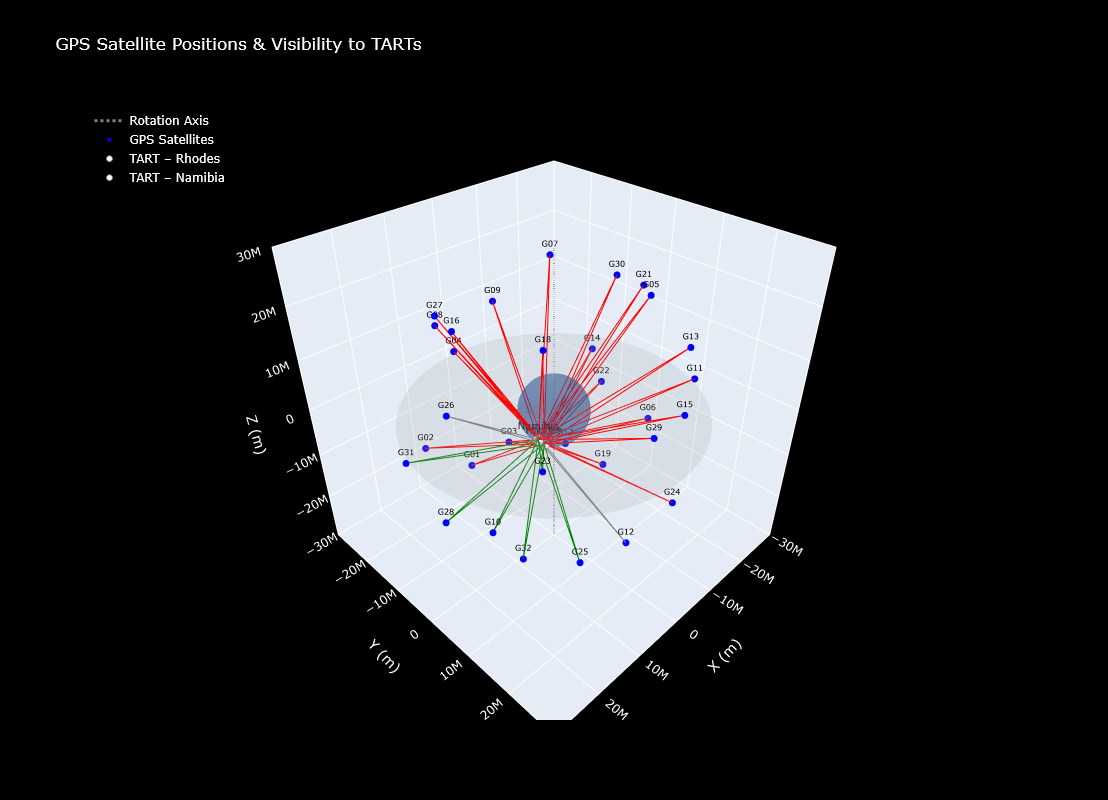

In [11]:
# Get the positions and satellite_ids as arrays from the dict
GPS_positions = []
for sat_id, position in GPS_positions_dict.items():
    GPS_positions.append(position)
sat_ids = np.array(list(GPS_positions_dict.keys()))
GPS_positions = np.array(GPS_positions)

fig = go.Figure()

# ── 1. Oblate Earth surface ─────────────────────────────────────────────
fig.add_trace(go.Surface(
    x=earth_x, y=earth_y, z=earth_z,
    colorscale=[[0, 'rgb(30,80,160)'], [1, 'rgb(30,80,160)']],
    opacity=0.4,
    showscale=False,
    name='Earth',
    hoverinfo='skip',
))

# ── 1b. Rotation axis (Z-axis in ECEF) ──────────────────────────────────
axis_half_length = 3.5e7
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=[-axis_half_length, axis_half_length],
    mode='lines',
    line=dict(color='grey', width=3, dash='dot'),
    name='Rotation Axis',
    hoverinfo='skip',
))

# ── 1c. Equatorial plane disk (z=0) ─────────────────────────────────────
max_sat_dist = np.nanmax(np.linalg.norm(GPS_positions, axis=1))
n_disk = 60
r_disk = np.linspace(0, max_sat_dist, 2)
theta_disk = np.linspace(0, 2 * np.pi, n_disk)
R, Theta = np.meshgrid(r_disk, theta_disk)
disk_x = R * np.cos(Theta)
disk_y = R * np.sin(Theta)
disk_z = np.zeros_like(R)
fig.add_trace(go.Surface(
    x=disk_x, y=disk_y, z=disk_z,
    colorscale=[[0, 'rgb(150,150,150)'], [1, 'rgb(150,150,150)']],
    opacity=0.2,
    showscale=False,
    name='Equatorial Plane',
    hoverinfo='skip',
))

# ── 2. GPS satellite positions ─────────────────────────────────────────
fig.add_trace(go.Scatter3d(
    x=GPS_positions[:, 0],
    y=GPS_positions[:, 1],
    z=GPS_positions[:, 2],
    mode='markers+text',
    marker=dict(size=4, color='blue', symbol='circle'),
    text=[str(s) for s in sat_ids],
    textposition='top center',
    textfont=dict(size=8, color='black'),
    name='GPS Satellites',
))

# ── 3. TART positions ───────────────────────────────────────────────────
tart_labels = ['Rhodes', 'Namibia']
tart_ecefs  = [rhodes_TART_ecef, namibia_TART_ecef]

for label, pos in zip(tart_labels, tart_ecefs):
    fig.add_trace(go.Scatter3d(
        x=[pos[0]], y=[pos[1]], z=[pos[2]],
        mode='markers+text',
        marker=dict(size=6, color='white', symbol='circle',
                    line=dict(width=1, color='grey')),
        text=[label],
        textposition='top center',
        textfont=dict(size=10, color='black'),
        name=f'TART – {label}',
    ))

# ── 4. Satellite → TART vectors coloured by visibility ──────────────────
tart_site_keys = ['rhodes', 'namibia']

for i, sat_id in enumerate(sat_ids):
    sat_pos = GPS_positions[i]

    above_rhodes  = sat_id in viable_satellites.get('rhodes', [])
    above_namibia = sat_id in viable_satellites.get('namibia', [])

    if above_rhodes and above_namibia:
        color = 'green'
    elif above_rhodes or above_namibia:
        color = 'grey'
    else:
        color = 'red'

    for tart_label, tart_pos in zip(tart_labels, tart_ecefs):
        fig.add_trace(go.Scatter3d(
            x=[sat_pos[0], tart_pos[0]],
            y=[sat_pos[1], tart_pos[1]],
            z=[sat_pos[2], tart_pos[2]],
            mode='lines',
            line=dict(color=color, width=2),
            showlegend=False,
            hoverinfo='text',
            hovertext=f'{sat_id} → {tart_label}<br>'
                      f'Viable from Rhodes: {above_rhodes}<br>'
                      f'Viable from Namibia: {above_namibia}',
        ))

# ── Layout ───────────────────────────────────────────────────────────────
axis_range = 3e7
fig.update_layout(
    title='GPS Satellite Positions & Visibility to TARTs',
    scene=dict(
        xaxis=dict(title='X (m)', range=[-axis_range, axis_range]),
        yaxis=dict(title='Y (m)', range=[-axis_range, axis_range]),
        zaxis=dict(title='Z (m)', range=[-axis_range, axis_range]),
        aspectmode='cube',
        bgcolor='black',
    ),
    paper_bgcolor='black',
    font=dict(color='white'),
    legend=dict(x=0.01, y=0.99),
    width=1000,
    height=800,
)

fig.show()

## 4. Save to HTML

In [12]:
output_path = os.path.join(filepath, "GPS_positions_visualisation.html")
fig.write_html(output_path)
print(f"Saved interactive plot to: {output_path}")

Saved interactive plot to: /home/jdawson/repos/TART/notebooks/dataproducts/1770993565.3405828/GPS_positions_visualisation.html
